In [ ]:
## benchmark 方法：NicheCompass， GraphST， STAGATE， Cellcharter
## benchmark 数据集：
## metrics ref https://genomebiology.biomedcentral.com/articles/10.1186/s13059-024-03361-0

### seqFish 小鼠胚胎发生 data

In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
from sklearn import metrics
import multiprocessing as mp
import numpy as np
from GraphST import GraphST
from GraphST.utils import clustering

# Run device, by default, the package is implemented on 'cpu'. We recommend using GPU.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [2]:
# Define paths
import os

st_data_folder_path = "/pri_exthome/zhouwg/project/spatial_data" # spatially resolved transcriptomics data
st_data_silver_folder_path = f"{st_data_folder_path}/silver"
st_data_gold_folder_path = f"{st_data_folder_path}/gold"
# Create required directories
os.makedirs(st_data_silver_folder_path, exist_ok=True)
os.makedirs(st_data_gold_folder_path, exist_ok=True)

dataset = "seqfish_mouse_organogenesis"
cell_type_key = "celltype_mapped_refined"

In [4]:
# Load data
dataset = "seqfish_mouse_organogenesis"
cell_type_key = "celltype_mapped_refined"

adata_list = []
batch_indeces = list(np.arange(6) + 1)
batches = ["embryo1_z2",
           "embryo1_z5",
           "embryo2_z2",
           "embryo2_z5",
           "embryo3_z2",
           "embryo3_z5"]

for batch_idx, batch in zip(batch_indeces, batches):
    adata = sc.read_h5ad(f"{st_data_gold_folder_path}/{dataset}_batch{batch_idx}.h5ad")
    adata.var_names_make_unique(join="++")
    # make spot name unique
    # adata.obs_names = [x+'_'+batch for x in adata.obs_names]
    adata_list.append(adata)

In [5]:
import anndata as ad

adata_concat = ad.concat(adata_list, label="slice_name", keys=batches)
adata_concat

AnnData object with n_obs × n_vars = 52568 × 351
    obs: 'Area', 'celltype_mapped_refined', 'sample', 'batch', 'slice_name'
    obsm: 'spatial'
    layers: 'counts'

In [7]:
# the number of clusters
n_clusters = len(np.unique(adata_concat.obs[cell_type_key]))
n_clusters

23

In [6]:
# define model
model = GraphST.GraphST(adata_concat, device=device)

# train model
adata = model.train()

/home/zhouwg/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


Begin to train ST data...


100%|██████████| 600/600 [04:11<00:00,  2.39it/s]


Optimization finished for ST data!


In [13]:
# set radius to specify the number of neighbors considered during refinement
radius = 50

tool = 'leiden' # mclust, leiden, and louvain

# clustering
from GraphST.utils import clustering

if tool == 'mclust':
   clustering(adata, n_clusters, radius=radius, method=tool, refinement=True)
elif tool in ['leiden', 'louvain']:
   clustering(adata, n_clusters, radius=radius, method=tool, start=1.0, end=2.0, increment=0.05, refinement=False)

Searching resolution...
resolution=1.9500000000000008, cluster number=25
resolution=1.9000000000000008, cluster number=27
resolution=1.8500000000000008, cluster number=26
resolution=1.8000000000000007, cluster number=26
resolution=1.7500000000000007, cluster number=23


In [14]:
adata

AnnData object with n_obs × n_vars = 52568 × 351
    obs: 'Area', 'celltype_mapped_refined', 'sample', 'batch', 'slice_name', 'leiden', 'domain'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'leiden'
    obsm: 'spatial', 'distance_matrix', 'graph_neigh', 'adj', 'label_CSL', 'feat', 'feat_a', 'emb', 'emb_pca'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [16]:
# calculate metric ARI
ARI = metrics.adjusted_rand_score(adata.obs['domain'], adata.obs['celltype_mapped_refined'])
adata.uns['ARI'] = ARI

print('Dataset:', dataset)
print('ARI:', ARI)

Dataset: seqfish_mouse_organogenesis
ARI: 0.21533496929926077


In [18]:
# plotting predicted labels by UMAP
sc.pp.neighbors(adata, use_rep='emb_pca', n_neighbors=10)
sc.tl.umap(adata)

/home/zhouwg/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/zhouwg/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


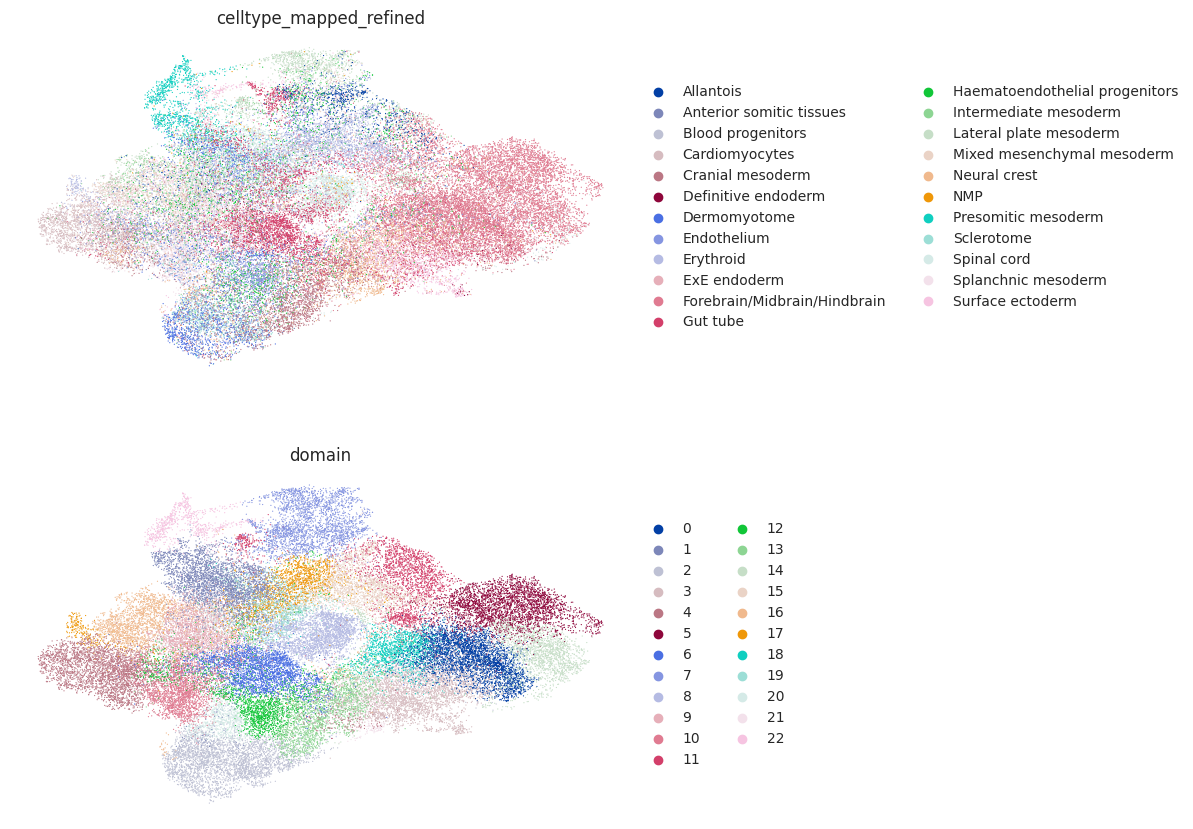

In [19]:
sc.pl.umap(adata, color=['celltype_mapped_refined', 'domain'],
           show=True, wspace=0.35, size=3, frameon=False, ncols=1)

In [20]:
## save adata
res_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'
adata.write(f"{res_dir}/{dataset}_GraphST.h5ad")

In [ ]:
# load adata
adata = sc.read(f"{res_dir}/{dataset}_GraphST.h5ad")
adata

### dendrogram analysis

In [1]:
import os
import pandas as pd
import numpy as np

os.chdir('/pri_exthome/zhouwg/project/Garfield')
os.getcwd()

'/pri_exthome/zhouwg/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
import numpy as np
import pandas as pd
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouwg/anaconda3/envs/env_gf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.3.8'

In [10]:
import re

from matplotlib import pyplot as plt
import matplotlib
matplotlib.use("Agg") #使用非交互式的后端生成图像文件

def pic(pdf):
    searchObj = re.search( r'(.*).pdf', pdf)
    png = f"{searchObj.group(1)}.png"
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, bbox_inches="tight", dpi=300)
    plt.close()

In [3]:
# Define paths
import os

work_dir = "/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_slideseqv2/model"
cell_type_key = "niche_type"

In [4]:
# Load data
adata = sc.read_h5ad(f"{work_dir}/adata_ref.h5ad")
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 41786 × 3000
    obs: 'cell_type', 'n_genes', 'latent_leiden_0.5', 'latent_leiden_0.8', 'niche_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'garfield_latent', 'hvg', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'latent_leiden_0.8', 'latent_leiden_0.8_colors', 'log1p', 'neighbors', 'niche_type_colors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'feat', 'garfield_latent', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'distances', 'garfield_latent_connectivities', 'garfield_latent_distances', 'spatial_connectivities'

In [5]:
sc.tl.dendrogram(adata=adata,
                 use_rep="garfield_latent",
                 linkage_method="single",
                 groupby="niche_type")
# plt.show()
# pic(os.path.join(res_dir, "00.dendrogram_garfield_latent.pdf"))

In [11]:
sc.settings.set_figure_params(dpi=100, facecolor='white')

fig, (ax) = plt.subplots(1, 1, figsize=(3, 8))
sc.pl.dendrogram(
    adata=adata,
    groupby="niche_type",
    orientation="left",
    ax=ax)

res_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_slideseqv2'
pic(os.path.join(res_dir, "06.dendrogram_garfield_latent.pdf"))

### 小鼠海马体数据 slideseqv2_mouse_hippocampus

#### GraphST

In [3]:
import pandas as pd
import scanpy as sc

In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
from sklearn import metrics
import multiprocessing as mp
import numpy as np
from GraphST import GraphST
from GraphST.utils import clustering

# Run device, by default, the package is implemented on 'cpu'. We recommend using GPU.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [4]:
# Define paths
import os

work_dir = "/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_slideseqv2/model"
cell_type_key = "niche_type"

In [5]:
# Load data
adata = sc.read_h5ad(f"{work_dir}/adata_ref.h5ad")
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 41786 × 3000
    obs: 'cell_type', 'n_genes', 'latent_leiden_0.5', 'latent_leiden_0.8', 'niche_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'garfield_latent', 'hvg', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'latent_leiden_0.8', 'latent_leiden_0.8_colors', 'log1p', 'neighbors', 'niche_type_colors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'feat', 'garfield_latent', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'distances', 'garfield_latent_connectivities', 'garfield_latent_distances', 'spatial_connectivities'

In [4]:
# the number of clusters
n_clusters = len(np.unique(adata.obs[cell_type_key]))
n_clusters

10

In [5]:
del adata.obsm['feat']

In [6]:
# define model
model = GraphST.GraphST(adata, device=device)

# train model
adata = model.train()

Begin to train ST data...


100%|██████████| 600/600 [12:26<00:00,  1.24s/it]


Optimization finished for ST data!


In [8]:
# set radius to specify the number of neighbors considered during refinement
radius = 50

tool = 'leiden' # mclust, leiden, and louvain

# clustering
from GraphST.utils import clustering

if tool == 'mclust':
   clustering(adata, n_clusters, radius=radius, method=tool, refinement=True)
elif tool in ['leiden', 'louvain']:
   clustering(adata, n_clusters, radius=radius, method=tool, start=0.2, end=0.4, increment=0.05, refinement=False)

Searching resolution...
resolution=0.35, cluster number=10


In [9]:
adata

AnnData object with n_obs × n_vars = 41786 × 3000
    obs: 'cell_type', 'n_genes', 'latent_leiden_0.5', 'latent_leiden_0.8', 'niche_type', 'leiden', 'domain'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'garfield_latent', 'hvg', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'latent_leiden_0.8', 'latent_leiden_0.8_colors', 'log1p', 'neighbors', 'niche_type_colors', 'pca', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap', 'garfield_latent', 'spatial', 'distance_matrix', 'graph_neigh', 'adj', 'label_CSL', 'feat', 'feat_a', 'emb', 'emb_pca'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'distances', 'garfield_latent_connectivities', 'garfield_latent_distances', 'spatial_connectivities'

In [11]:
# calculate metric ARI
ARI = metrics.adjusted_rand_score(adata.obs['domain'], adata.obs['niche_type'])
adata.uns['ARI'] = ARI

# print('Dataset:', dataset)
print('ARI:', ARI)

ARI: 0.4091515833601205


In [12]:
from sklearn import metrics
import numpy as np

def calculate_metric(pred, label):
    # 计算 NMI 和 ARI
    nmi = np.round(metrics.normalized_mutual_info_score(label, pred), 4)
    ari = np.round(metrics.adjusted_rand_score(label, pred), 4)

    # 计算 AMI
    ami = np.round(metrics.adjusted_mutual_info_score(label, pred), 4)

    # 计算 HOM (Homogeneity)
    homogeneity = np.round(metrics.homogeneity_score(label, pred), 4)

    return nmi, ari, ami, homogeneity


nmi, ari, ami, homogeneity = calculate_metric(adata.obs['domain'], adata.obs['niche_type'])
print(f"NMI: {nmi}, ARI: {ari}, AMI: {ami}, HOM: {homogeneity}")

NMI: 0.4784, ARI: 0.4092, AMI: 0.4781, HOM: 0.4847


In [13]:
# plotting predicted labels by UMAP
sc.pp.neighbors(adata, use_rep='emb_pca', n_neighbors=10)
sc.tl.umap(adata)

/home/zhouwg/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/zhouwg/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


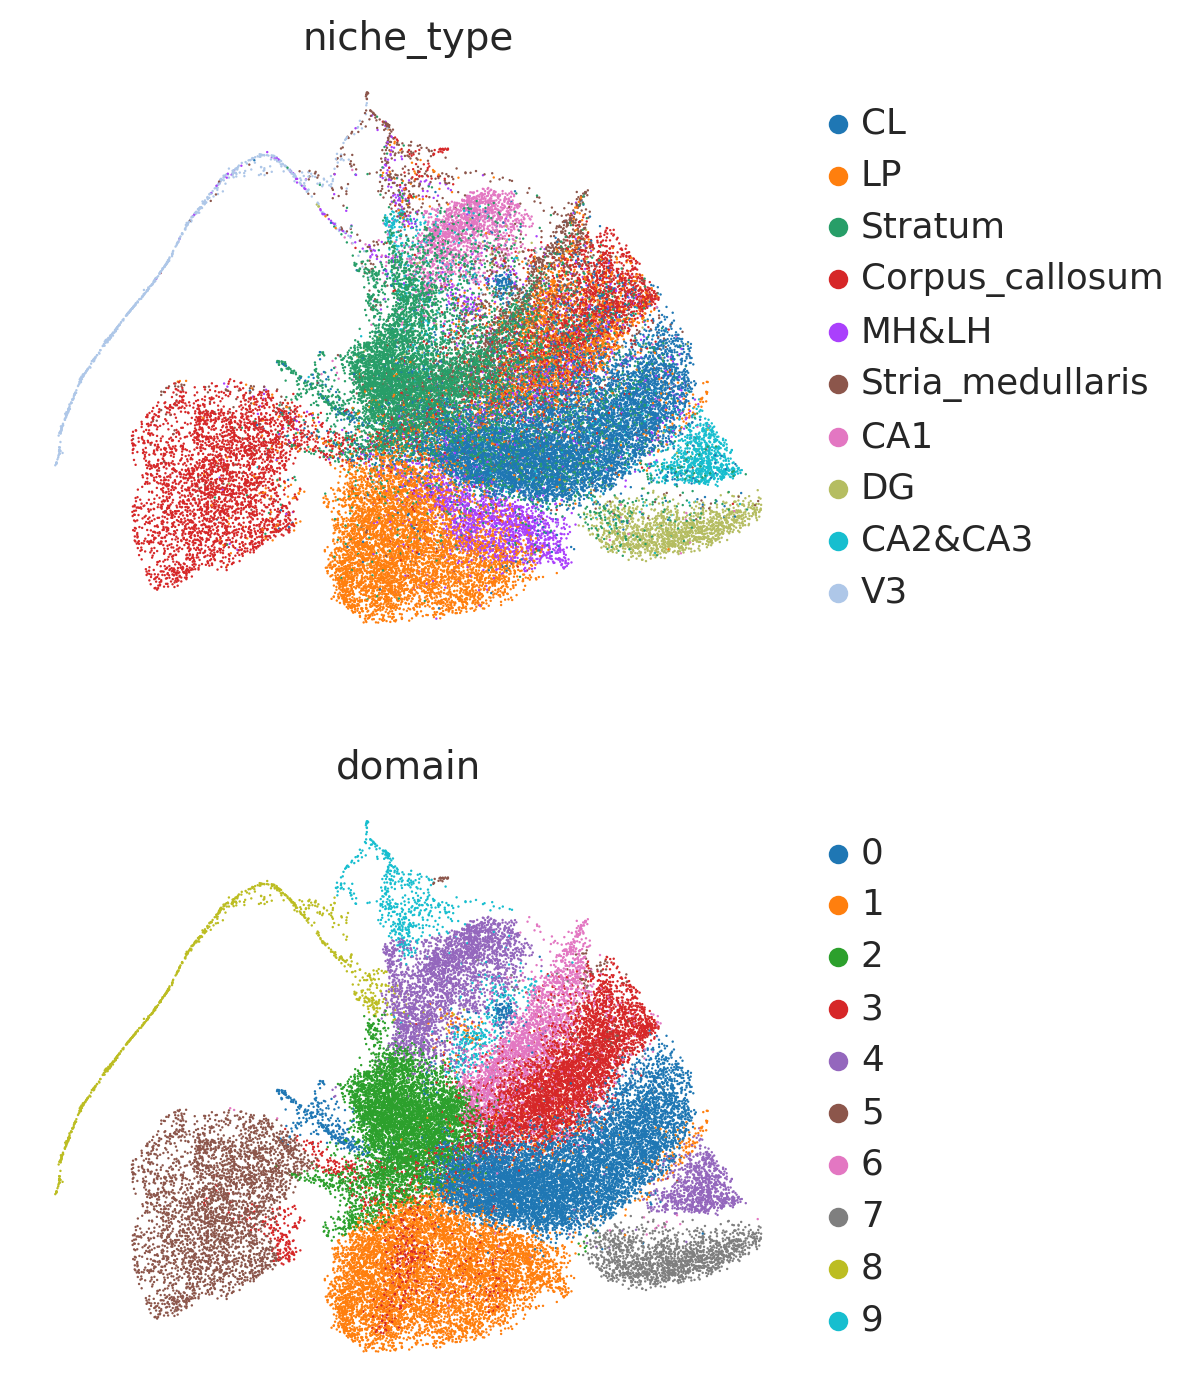

In [15]:
sc.settings.set_figure_params(dpi=100, facecolor='white')

sc.pl.umap(adata, color=['niche_type', 'domain'],
           show=True, wspace=0.35, size=3, frameon=False, ncols=1)

In [16]:
## save adata
res_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'
adata.write(f"{res_dir}/slideseqv2_GraphST.h5ad")

# GraphST

In [2]:
import os
import time
from datetime import datetime

import matplotlib.pyplot as plt
import multiprocessing as mp
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
# import squidpy as sq
import torch
from GraphST import GraphST
from sklearn import metrics

### 1.2 Define Parameters

In [3]:
model_name = "graphst"
latent_key = f"{model_name}_latent"

### 1.3 Run Notebook Setup

In [4]:
sc.set_figure_params(figsize=(6, 6))

In [5]:
# Get time of notebook execution for timestamping saved artifacts
now = datetime.now()
current_timestamp = now.strftime("%d%m%Y_%H%M%S")

### 1.4 Configure Paths and Directories

In [6]:
data_folder_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal/'
benchmarking_folder_path = "/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal"
figure_folder_path = f"../../../figures"

## 2. GraphST Model

### 2.1 Define Training Function

In [9]:
# Run device. By default, the package is implemented on 'cpu'. It is recommended to use GPU.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def train_graphst_models(dataset,
                         cell_type_key,
                         niche_type_key=None,
                         adata_new=None,
                         n_start_run=1,
                         n_end_run=8,
                         n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16]):
    # Configure figure folder path
    # dataset_figure_folder_path = f"{figure_folder_path}/{dataset}/single_sample_method_benchmarking/" \
    #                              f"{model_name}/{current_timestamp}"
    # os.makedirs(dataset_figure_folder_path, exist_ok=True)

    # Create new adata to store results from training runs in storage-efficient way
    if adata_new is None:
        adata_original = sc.read_h5ad(data_folder_path + f"{dataset}.h5ad")
        adata_new = sc.AnnData(sp.csr_matrix(
            (adata_original.shape[0], adata_original.shape[1]),
            dtype=np.float32))
        adata_new.var_names = adata_original.var_names
        adata_new.obs_names = adata_original.obs_names
        adata_new.obs["cell_type"] = adata_original.obs[cell_type_key].values
        if niche_type_key in adata_original.obs.columns:
            adata_new.obs["niche_type"] = adata_original.obs[niche_type_key].values
        adata_new.obsm["spatial"] = adata_original.obsm["spatial"]
        del(adata_original)

    model_seeds = list(range(10))
    for run_number, n_neighbors in zip(np.arange(n_start_run, n_end_run+1), n_neighbor_list):
        # Load data
        adata = sc.read_h5ad(data_folder_path + f"{dataset}.h5ad")
        del adata.obsm['feat']

        # Store raw counts in adata.X
        adata.X = adata.layers["counts"]
        if "log1p" in adata.uns:
            del(adata.uns["log1p"])

        # Compute spatial neighborhood graph
        # sq.gr.spatial_neighbors(adata,
        #                         coord_type="generic",
        #                         spatial_key="spatial",
        #                         n_neighs=n_neighbors)
        # adata.obsm["graph_neigh"] = adata.obsp["spatial_connectivities"]
        #
        # # Make adjacency matrix symmetric
        # adata.obsm["adj"] = adata.obsm["graph_neigh"].maximum(
        #     adata.obsm["graph_neigh"].T)

        start_time = time.time()

        # Define model
        model = GraphST.GraphST(adata,
                                device=device,
                                random_seed=model_seeds[run_number-1])

        # Train model
        adata = model.train()

        # Measure time for model training
        end_time = time.time()
        elapsed_time = end_time - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"Duration of model training in run {run_number}: "
              f"{int(hours)} hours, {int(minutes)} minutes and {int(seconds)} seconds.")
        adata_new.uns[f"{model_name}_model_training_duration_run{run_number}"] = (
            elapsed_time)

        adata_new.obsm[latent_key + f"_run{run_number}"] = adata.obsm["emb"]

        # Store intermediate adata to disk
        adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

    # Store final adata to disk
    adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

### 2.2 Train Models on Benchmarking Datasets

In [10]:
train_graphst_models(dataset="adata_slideseqv2",
                     cell_type_key="cell_type",
                     niche_type_key="niche_type",
                     adata_new=None,
                     n_start_run=1,
                     n_end_run=8,
                     n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16])

Begin to train ST data...


100%|██████████| 600/600 [12:27<00:00,  1.25s/it]


Optimization finished for ST data!
Duration of model training in run 1: 0 hours, 16 minutes and 44 seconds.
Begin to train ST data...


100%|██████████| 600/600 [12:25<00:00,  1.24s/it]


Optimization finished for ST data!
Duration of model training in run 2: 0 hours, 16 minutes and 16 seconds.
Begin to train ST data...


...

Optimization finished for ST data!
Duration of model training in run 6: 0 hours, 16 minutes and 41 seconds.
Begin to train ST data...


100%|██████████| 600/600 [12:25<00:00,  1.24s/it]


Optimization finished for ST data!
Duration of model training in run 7: 0 hours, 16 minutes and 53 seconds.
Begin to train ST data...


100%|██████████| 600/600 [12:19<00:00,  1.23s/it]


Optimization finished for ST data!
Duration of model training in run 8: 0 hours, 16 minutes and 44 seconds.


# scVI

In [6]:
import os
import time
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import scipy.sparse as sp
import scvi
# import squidpy as sq

### 1.2 Define Parameters

In [7]:
model_name = "scvi"
latent_key = f"{model_name}_latent"

### 1.3 Run Notebook Setup

In [8]:
sc.set_figure_params(figsize=(6, 6))

In [9]:
# Get time of notebook execution for timestamping saved artifacts
now = datetime.now()
current_timestamp = now.strftime("%d%m%Y_%H%M%S")

### 1.4 Configure Paths and Directories

In [13]:
data_folder_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal/'
benchmarking_folder_path = "/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal"
figure_folder_path = f"../../../figures"

## 2. scVI Model

### 2.1 Define Training Function

In [11]:
def train_scvi_models(dataset,
                      cell_type_key,
                      niche_type_key=None,
                      adata_new=None,
                      n_start_run=1,
                      n_end_run=8,
                      n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16]):
    # Configure figure folder path
    # dataset_figure_folder_path = f"{figure_folder_path}/{dataset}/single_sample_method_benchmarking/" \
    #                              f"{model_name}/{current_timestamp}"
    # os.makedirs(dataset_figure_folder_path, exist_ok=True)

    # Create new adata to store results from training runs in storage-efficient way
    if adata_new is None:
        adata_original = sc.read_h5ad(data_folder_path + f"{dataset}.h5ad")
        adata_new = sc.AnnData(sp.csr_matrix(
            (adata_original.shape[0], adata_original.shape[1]),
            dtype=np.float32))
        adata_new.var_names = adata_original.var_names
        adata_new.obs_names = adata_original.obs_names
        adata_new.obs["cell_type"] = adata_original.obs[cell_type_key].values
        if niche_type_key in adata_original.obs.columns:
            adata_new.obs["niche_type"] = adata_original.obs[niche_type_key].values
        adata_new.obsm["spatial"] = adata_original.obsm["spatial"]
        del(adata_original)

    model_seeds = list(range(10))
    for run_number, n_neighbors in zip(np.arange(n_start_run, n_end_run+1), n_neighbor_list):
        # n_neighbors is here only used for the latent neighbor graph construction used for
        # UMAP generation and clustering as scVI is not a spatial method

        # Load data
        adata = sc.read_h5ad(data_folder_path + f"{dataset}.h5ad")
        del adata.obsm['feat']

        start_time = time.time()

        scvi.settings.seed = model_seeds[run_number-1]

        # Setup adata
        scvi.model.SCVI.setup_anndata(adata,
                                      layer="counts")

        # Initialize model
        model = scvi.model.SCVI(adata)

        # Train model
        model.train()

        adata.obsm[latent_key] = model.get_latent_representation()

        # Measure time for model training
        end_time = time.time()
        elapsed_time = end_time - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"Duration of model training in run {run_number}: "
              f"{int(hours)} hours, {int(minutes)} minutes and {int(seconds)} seconds.")
        adata_new.uns[f"{model_name}_model_training_duration_run{run_number}"] = (
            elapsed_time)

        # Store latent representation
        adata_new.obsm[latent_key + f"_run{run_number}"] = adata.obsm[latent_key]

        # Store intermediate adata to disk
        adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

    # Store final adata to disk
    adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

### 2.2 Train Models on Benchmarking Datasets

In [14]:
train_scvi_models(dataset="adata_slideseqv2",
                  cell_type_key="cell_type",
                  niche_type_key="niche_type",
                  adata_new=None,
                  n_start_run=1,
                  n_end_run=8,
                  n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16])

Seed set to 0
Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
/home/zhouwg/anaconda3/envs/scvi/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/zhouwg/anaconda3/envs/scvi/lib/python3.10/site ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zhouwg/anaconda3/envs/scvi/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend 

Epoch 191/191: 100%|██████████| 191/191 [07:16<00:00,  2.47s/it, v_num=1, train_loss_step=174, train_loss_epoch=170]

`Trainer.fit` stopped: `max_epochs=191` reached.


Epoch 191/191: 100%|██████████| 191/191 [07:16<00:00,  2.29s/it, v_num=1, train_loss_step=174, train_loss_epoch=170]


Seed set to 1


...

Duration of model training in run 7: 0 hours, 6 minutes and 56 seconds.


Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
/home/zhouwg/anaconda3/envs/scvi/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/zhouwg/anaconda3/envs/scvi/lib/python3.10/site ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zhouwg/anaconda3/envs/scvi/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python co

Epoch 191/191: 100%|██████████| 191/191 [06:56<00:00,  1.99s/it, v_num=1, train_loss_step=176, train_loss_epoch=170]

`Trainer.fit` stopped: `max_epochs=191` reached.


Epoch 191/191: 100%|██████████| 191/191 [06:56<00:00,  2.18s/it, v_num=1, train_loss_step=176, train_loss_epoch=170]
Duration of model training in run 8: 0 hours, 6 minutes and 56 seconds.


# Cellcharter

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [3]:
import os
import time
from datetime import datetime

import anndata as ad
import cellcharter as cc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import squidpy as sq

/home/zhouwg/anaconda3/envs/cellcharter/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/home/zhouwg/anaconda3/envs/cellcharter/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.2 Define Parameters

In [4]:
model_name = "cellcharter"
latent_key = f"{model_name}_latent"

### 1.3 Run Notebook Setup

In [5]:
sc.set_figure_params(figsize=(6, 6))

In [6]:
# Get time of notebook execution for timestamping saved artifacts
now = datetime.now()
current_timestamp = now.strftime("%d%m%Y_%H%M%S")

### 1.4 Configure Paths and Directories

In [10]:
data_folder_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal/'
benchmarking_folder_path = "/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal"
figure_folder_path = f"../../../figures"

## 2. CellCharter Model

### 2.1 Define Training Function

In [8]:
def train_cellcharter_models(dataset,
                             cell_type_key,
                             niche_type_key=None,
                             adata_new=None,
                             n_start_run=1,
                             n_end_run=8,
                             n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16]):
    # Configure figure folder path
    # dataset_figure_folder_path = f"{figure_folder_path}/{dataset}/single_sample_method_benchmarking/" \
    #                              f"{model_name}/{current_timestamp}"
    # os.makedirs(dataset_figure_folder_path, exist_ok=True)

    # Create new adata to store results from training runs in storage-efficient way
    if adata_new is None:
        adata_original = sc.read_h5ad(data_folder_path + f"{dataset}.h5ad")
        adata_new = sc.AnnData(sp.csr_matrix(
            (adata_original.shape[0], adata_original.shape[1]),
            dtype=np.float32))
        adata_new.var_names = adata_original.var_names
        adata_new.obs_names = adata_original.obs_names
        adata_new.obs["cell_type"] = adata_original.obs[cell_type_key].values
        if niche_type_key in adata_original.obs.columns:
            adata_new.obs["niche_type"] = adata_original.obs[niche_type_key].values
        adata_new.obsm["spatial"] = adata_original.obsm["spatial"]
        del(adata_original)

    model_seeds = list(range(10))
    for run_number, n_neighbors in zip(np.arange(n_start_run, n_end_run+1), n_neighbor_list):
        # n_neighbors is here only used for the latent neighbor graph construction used for
        # UMAP generation and clustering as scVI is not a spatial method

        # Load trained SCVI results
        adata = sc.read_h5ad(f"{benchmarking_folder_path}/{dataset}_scvi.h5ad")

        start_time = time.time()

        adata.obsm["latent_scvi"] = adata.obsm[f"scvi_latent_run{run_number}"].astype(np.float32)

        # Compute spatial neighborhood graph
        sq.gr.spatial_neighbors(adata,
                                coord_type="generic",
                                spatial_key="spatial",
                                n_neighs=n_neighbors)

        # Use CellCharter as per tutorial
        cc.gr.remove_long_links(adata)
        cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep="latent_scvi", out_key=latent_key)

        # Measure time for model training
        end_time = time.time()
        elapsed_time = end_time - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"Duration of model training in run {run_number}: "
              f"{int(hours)} hours, {int(minutes)} minutes and {int(seconds)} seconds.")
        adata_new.uns[f"{model_name}_model_training_duration_run{run_number}"] = (
            adata.uns[f"scvi_model_training_duration_run{run_number}"] + elapsed_time)

        # Store latent representation
        adata_new.obsm[latent_key + f"_run{run_number}"] = adata.obsm[latent_key]

        # Store intermediate adata to disk
        adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

    # Store final adata to disk
    adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

### 2.2 Train Models on Benchmarking Datasets

In [11]:
train_cellcharter_models(dataset="adata_slideseqv2",
                         cell_type_key="cell_type",
                         niche_type_key="niche_type",
                         adata_new=None,
                         n_start_run=1,
                         n_end_run=8,
                         n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16])

100%|██████████| 4/4 [00:00<00:00, 48.62it/s]


Duration of model training in run 1: 0 hours, 0 minutes and 0 seconds.


100%|██████████| 4/4 [00:00<00:00, 44.89it/s]


Duration of model training in run 2: 0 hours, 0 minutes and 0 seconds.


100%|██████████| 4/4 [00:00<00:00, 17.23it/s]


...

Duration of model training in run 6: 0 hours, 0 minutes and 1 seconds.


100%|██████████| 4/4 [00:00<00:00,  6.97it/s]


Duration of model training in run 7: 0 hours, 0 minutes and 1 seconds.


100%|██████████| 4/4 [00:00<00:00,  7.10it/s]

Duration of model training in run 8: 0 hours, 0 minutes and 1 seconds.


# NicheCompass

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
import gc
import os
import sys
import time
from datetime import datetime

import anndata as ad
import numpy as np
import scanpy as sc
import scipy.sparse as sp
import squidpy as sq
import torch

from nichecompass.models import NicheCompass
from nichecompass.utils import (add_gps_from_gp_dict_to_adata,
                                extract_gp_dict_from_mebocost_ms_interactions,
                                extract_gp_dict_from_nichenet_lrt_interactions,
                                extract_gp_dict_from_omnipath_lr_interactions,
                                filter_and_combine_gp_dict_gps,
                                filter_and_combine_gp_dict_gps_v2,
                                get_unique_genes_from_gp_dict)

/home/zhouwg/anaconda3/envs/nichecompass/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/home/zhouwg/anaconda3/envs/nichecompass/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.2 Define Parameters

In [3]:
model_name = "nichecompass"
latent_key = f"{model_name}_latent"

### Dataset ###
dataset = "adata_slideseqv2"
species = "mouse"
spatial_key = "spatial"
# n_neighbors = 4

### Model ###
# AnnData Keys
counts_key = "counts"
adj_key = "spatial_connectivities"
gp_names_key = "nichecompass_gp_names"
active_gp_names_key = "nichecompass_active_gp_names"
gp_targets_mask_key = "nichecompass_gp_targets"
gp_targets_categories_mask_key = "nichecompass_gp_targets_categories"
gp_sources_mask_key = "nichecompass_gp_sources"
gp_sources_categories_mask_key = "nichecompass_gp_sources_categories"

# Architecture
conv_layer_encoder = "gcnconv" # change to "gatv2conv" if enough compute and memory
active_gp_thresh_ratio = 0.01

# Trainer
n_epochs = 400
n_epochs_all_gps = 25
lr = 0.001
lambda_edge_recon = 500000.
lambda_gene_expr_recon = 300.
lambda_l1_masked = 0. # prior GP  regularization
lambda_l1_addon = 30. # de novo GP regularization
edge_batch_size = 1024 # increase if more memory available or decrease to save memory
n_sampled_neighbors = 4
use_cuda_if_available = True

### Analysis ###
cell_type_key = "cell_type"
latent_leiden_resolution = 0.4
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
sample_key = "batch"
spot_size = 0.2
differential_gp_test_results_key = "nichecompass_differential_gp_test_results"

### 1.3 Run Notebook Setup

In [4]:
sc.set_figure_params(figsize=(6, 6))

In [5]:
# Get time of notebook execution for timestamping saved artifacts
now = datetime.now()
current_timestamp = now.strftime("%d%m%Y_%H%M%S")

### 1.4 Configure Paths and Directories

In [6]:
###############################################################################
### 1.3 Configure Paths and Create Directories ###
###############################################################################
# Define paths
ga_data_folder_path = "/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal/nichecompass/data/gene_annotations"
gp_data_folder_path = "/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal/nichecompass/data/gene_programs"
so_data_folder_path = "/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal/nichecompass/data/spatial_omics"
omnipath_lr_network_file_path = f"{gp_data_folder_path}/omnipath_lr_network.csv"
collectri_tf_network_file_path = f"{gp_data_folder_path}/collectri_tf_network_{species}.csv"
nichenet_lr_network_file_path = f"{gp_data_folder_path}/nichenet_lr_network_v2_{species}.csv"
nichenet_ligand_target_matrix_file_path = f"{gp_data_folder_path}/nichenet_ligand_target_matrix_v2_{species}.csv"
mebocost_enzyme_sensor_interactions_folder_path = f"{gp_data_folder_path}/metabolite_enzyme_sensor_gps"
gene_orthologs_mapping_file_path = f"{ga_data_folder_path}/human_mouse_gene_orthologs.csv"
artifacts_folder_path = f"/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal/nichecompass/artifacts"
model_folder_path = f"{artifacts_folder_path}/single_sample/{current_timestamp}/model"
figure_folder_path = f"{artifacts_folder_path}/single_sample/{current_timestamp}/figures"

In [7]:
os.makedirs(model_folder_path, exist_ok=True)
os.makedirs(figure_folder_path, exist_ok=True)
os.makedirs(so_data_folder_path, exist_ok=True)

In [8]:
data_folder_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal/'
benchmarking_folder_path = "/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal"

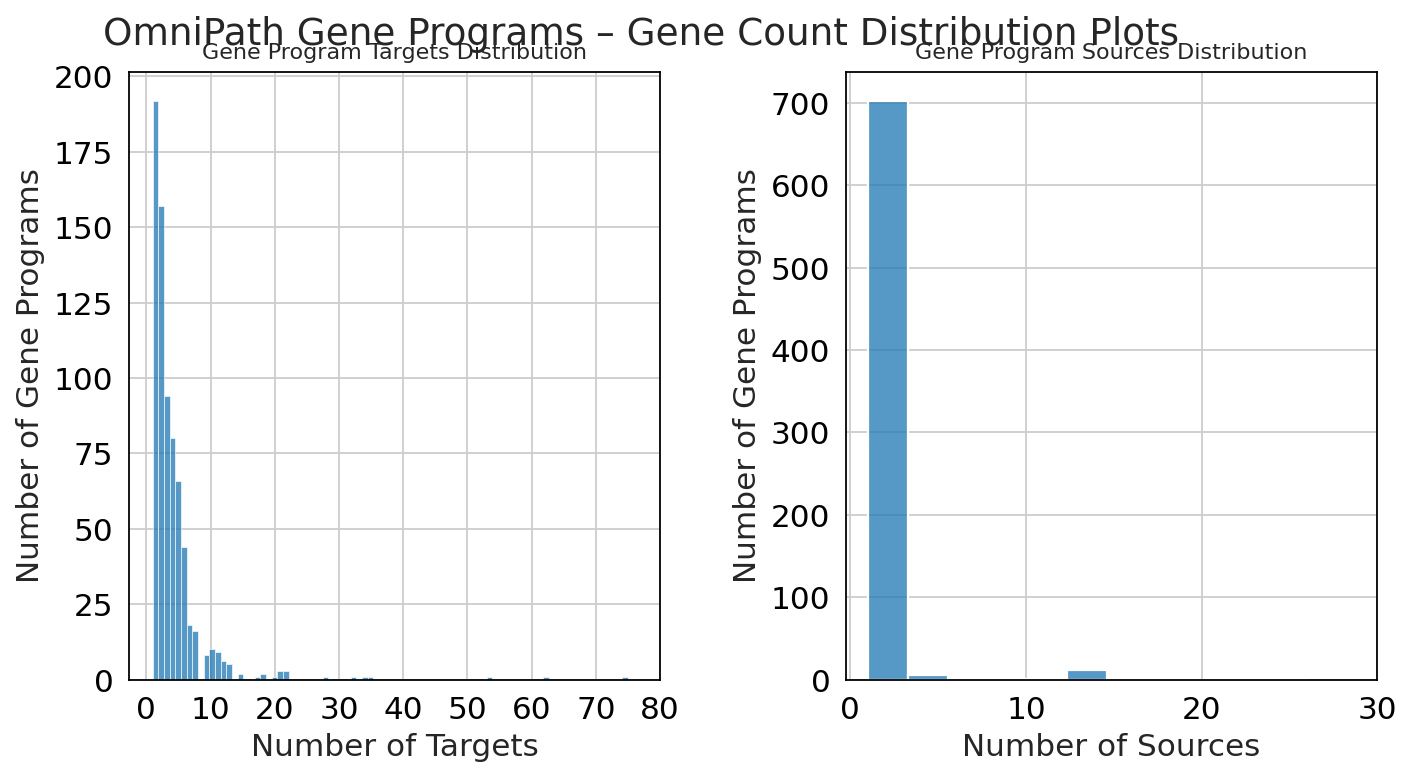

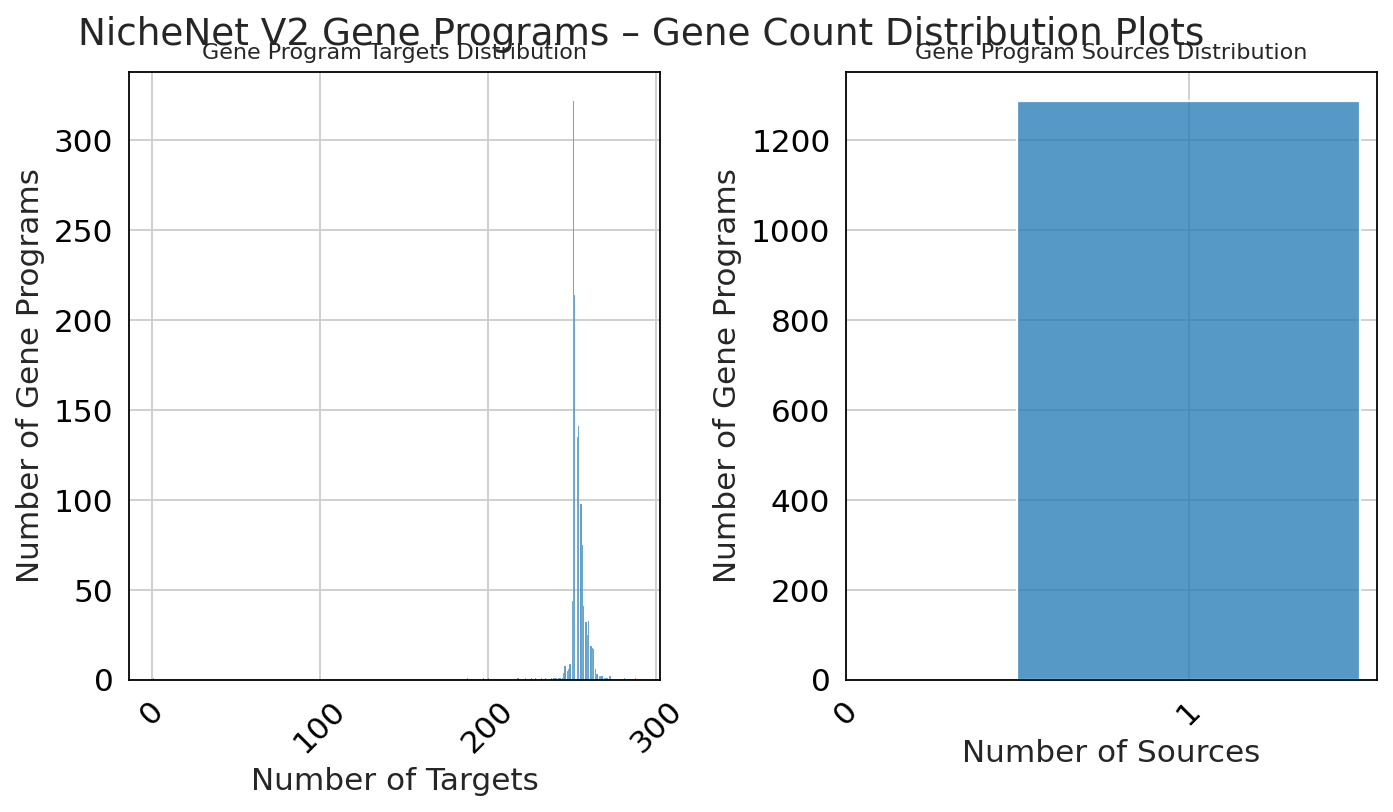

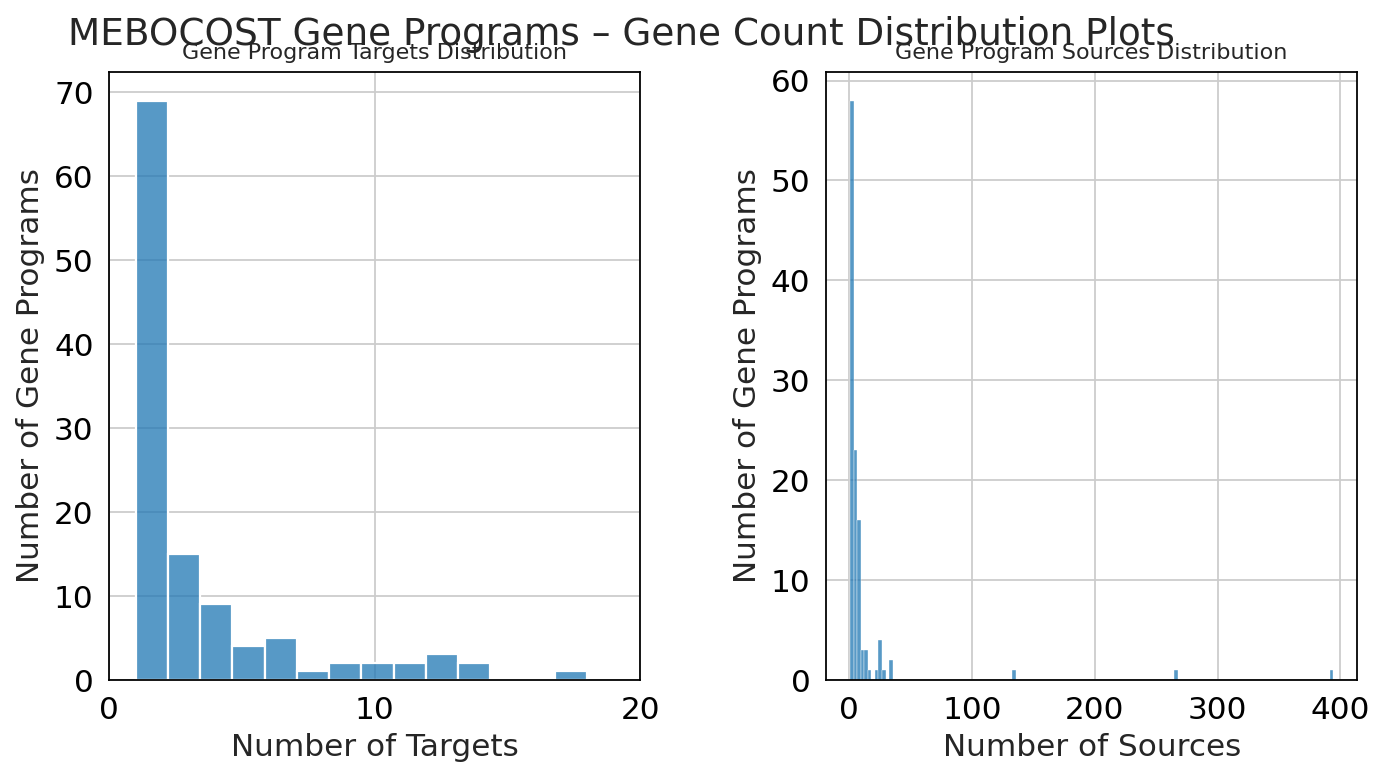

Combining ACE2_ligand_receptor_GP and Ace2_ligand_receptor_target_gene_GP.
Combining ACE2_ligand_receptor_GP and L-Phenylalanine_metabolite_enzyme_sensor_GP.
Combining ADCYAP1_ligand_receptor_GP and Adcyap1_ligand_receptor_target_gene_GP.
Combining ADGRE5_ligand_receptor_GP and Adgre5_ligand_receptor_target_gene_GP.
Combining ADIPOQ_ligand_receptor_GP and Adipoq_ligand_receptor_target_gene_GP.
Combining ADM_ligand_receptor_GP and Adm_ligand_receptor_target_gene_GP.
Combining ADM2_ligand_receptor_GP and Adm2_ligand_receptor_target_gene_GP.
Combining AGRP_ligand_receptor_GP and Agrp_ligand_receptor_target_gene_GP.
Combining AGT_ligand_receptor_GP and Agt_ligand_receptor_target_gene_GP.
Combining ALCAM_ligand_receptor_GP and Alcam_ligand_receptor_target_gene_GP.
Combining ALKAL1_ligand_receptor_GP and Alkal1_ligand_receptor_target_gene_GP.
Combining ALKAL2_ligand_receptor_GP and Alkal2_ligand_receptor_target_gene_GP.
Combining AMBN_ligand_receptor_GP and Ambn_ligand_receptor_target_gene_G

In [9]:
# Prepare Model Training
# Retrieve OmniPath GPs (source: ligand genes; target: receptor genes)
omnipath_gp_dict = extract_gp_dict_from_omnipath_lr_interactions(
    species=species,
    load_from_disk=False,
    save_to_disk=True,
    lr_network_file_path=omnipath_lr_network_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True,
    gp_gene_count_distributions_save_path=f"{figure_folder_path}" \
                                           "/omnipath_gp_gene_count_distributions.svg")

# Retrieve NicheNet GPs (source: ligand genes; target: receptor genes, target genes)
nichenet_gp_dict = extract_gp_dict_from_nichenet_lrt_interactions(
    species=species,
    version="v2",
    keep_target_genes_ratio=1.,
    max_n_target_genes_per_gp=250,
    load_from_disk=True,
    save_to_disk=True,
    lr_network_file_path=nichenet_lr_network_file_path,
    ligand_target_matrix_file_path=nichenet_ligand_target_matrix_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True)

# Retrieve MEBOCOST GPs (source: enzyme genes; target: sensor genes)
mebocost_gp_dict = extract_gp_dict_from_mebocost_ms_interactions(
    dir_path=mebocost_enzyme_sensor_interactions_folder_path,
    species=species,
    plot_gp_gene_count_distributions=True)

# Filter and combine GPs
gp_dicts = [omnipath_gp_dict, nichenet_gp_dict, mebocost_gp_dict]
combined_gp_dict = filter_and_combine_gp_dict_gps_v2(
    gp_dicts,
    verbose=True)

print(f"Number of gene programs after filtering and combining: "
      f"{len(combined_gp_dict)}.")

## 2. Nichecompass Model

### 2.1 Define Training Function

In [10]:
def train_nichecompass_models(dataset,
                             cell_type_key,
                             niche_type_key=None,
                             adata_new=None,
                             n_start_run=1,
                             n_end_run=8,
                             n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16]):
    # Configure figure folder path
    # dataset_figure_folder_path = f"{figure_folder_path}/{dataset}/single_sample_method_benchmarking/" \
    #                              f"{model_name}/{current_timestamp}"
    # os.makedirs(dataset_figure_folder_path, exist_ok=True)

    # Create new adata to store results from training runs in storage-efficient way
    if adata_new is None:
        adata_original = sc.read_h5ad(data_folder_path + f"{dataset}.h5ad")
        adata_new = sc.AnnData(sp.csr_matrix(
            (adata_original.shape[0], adata_original.shape[1]),
            dtype=np.float32))
        adata_new.var_names = adata_original.var_names
        adata_new.obs_names = adata_original.obs_names
        adata_new.obs["cell_type"] = adata_original.obs[cell_type_key].values
        if niche_type_key in adata_original.obs.columns:
            adata_new.obs["niche_type"] = adata_original.obs[niche_type_key].values
        adata_new.obsm["spatial"] = adata_original.obsm["spatial"]
        del(adata_original)

    model_seeds = list(range(10))
    for run_number, n_neighbors in zip(np.arange(n_start_run, n_end_run+1), n_neighbor_list):
        # n_neighbors is here only used for the latent neighbor graph construction used for
        # UMAP generation and clustering as scVI is not a spatial method

        # Load trained SCVI results
        adata = sc.read_h5ad(data_folder_path + f"{dataset}.h5ad")
        # Compute spatial neighborhood
        sq.gr.spatial_neighbors(adata,
                                coord_type="generic",
                                spatial_key=spatial_key,
                                n_neighs=n_neighbors)

        # Make adjacency matrix symmetric
        adata.obsp[adj_key] = (
            adata.obsp[adj_key].maximum(
                adata.obsp[adj_key].T))

        start_time = time.time()

        # Add the GP dictionary as binary masks to the adata
        add_gps_from_gp_dict_to_adata(
            gp_dict=combined_gp_dict,
            adata=adata,
            gp_targets_mask_key=gp_targets_mask_key,
            gp_targets_categories_mask_key=gp_targets_categories_mask_key,
            gp_sources_mask_key=gp_sources_mask_key,
            gp_sources_categories_mask_key=gp_sources_categories_mask_key,
            gp_names_key=gp_names_key,
            min_genes_per_gp=2,
            min_source_genes_per_gp=1,
            min_target_genes_per_gp=1,
            max_genes_per_gp=None,
            max_source_genes_per_gp=None,
            max_target_genes_per_gp=None)

        # Train Model
        # Initialize model
        model = NicheCompass(adata,
                             counts_key=counts_key,
                             adj_key=adj_key,
                             gp_names_key=gp_names_key,
                             active_gp_names_key=active_gp_names_key,
                             gp_targets_mask_key=gp_targets_mask_key,
                             gp_targets_categories_mask_key=gp_targets_categories_mask_key,
                             gp_sources_mask_key=gp_sources_mask_key,
                             gp_sources_categories_mask_key=gp_sources_categories_mask_key,
                             latent_key=latent_key,
                             conv_layer_encoder=conv_layer_encoder,
                             active_gp_thresh_ratio=active_gp_thresh_ratio)

        # Train model
        model.train(n_epochs=n_epochs,
                    n_epochs_all_gps=n_epochs_all_gps,
                    lr=lr,
                    lambda_edge_recon=lambda_edge_recon,
                    lambda_gene_expr_recon=lambda_gene_expr_recon,
                    lambda_l1_masked=lambda_l1_masked,
                    edge_batch_size=edge_batch_size,
                    n_sampled_neighbors=n_sampled_neighbors,
                    use_cuda_if_available=use_cuda_if_available,
                    verbose=False)

        # Compute latent neighbor graph
        # sc.pp.neighbors(model.adata,
        #                 use_rep=latent_key,
        #                 key_added=latent_key)
        #
        # # Compute UMAP embedding
        # sc.tl.umap(model.adata,
        #            neighbors_key=latent_key)

        # Measure time for model training
        end_time = time.time()
        elapsed_time = end_time - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"Duration of model training in run {run_number}: "
              f"{int(hours)} hours, {int(minutes)} minutes and {int(seconds)} seconds.")
        adata_new.uns[f"{model_name}_model_training_duration_run{run_number}"] = (
            elapsed_time)

        # Store latent representation
        adata_new.obsm[latent_key + f"_run{run_number}"] = model.adata.obsm[latent_key]

        # Store intermediate adata to disk
        adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

    # Store final adata to disk
    adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

### 2.2 Train Models on Benchmarking Datasets

In [ ]:
train_nichecompass_models(dataset="adata_slideseqv2",
                         cell_type_key="cell_type",
                         niche_type_key="niche_type",
                         adata_new=None,
                         n_start_run=1,
                         n_end_run=8,
                         n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16])

--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 3000, n_cat_covariates_embed_input: 0, n_hidden: 371, n_latent: 271, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 271, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 3000
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 271, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 3000

--- INITIALIZING TRAINER ---
Number of training nodes: 37607
Number of validation nodes: 4179
Number of training edges: 86394
Number of validation edges: 9599
Edge batch size: 1024
Node batch 

In [15]:
root_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'
adata = sc.read_h5ad(root_dir + '/adata_slideseqv2_nichecompass.h5ad')
adata

AnnData object with n_obs × n_vars = 41786 × 3000
    obs: 'cell_type', 'niche_type'
    uns: 'nichecompass_model_training_duration_run1', 'nichecompass_model_training_duration_run2', 'nichecompass_model_training_duration_run3', 'nichecompass_model_training_duration_run4', 'nichecompass_model_training_duration_run5', 'nichecompass_model_training_duration_run6', 'nichecompass_model_training_duration_run7', 'nichecompass_model_training_duration_run8'
    obsm: 'nichecompass_latent_run1', 'nichecompass_latent_run2', 'nichecompass_latent_run3', 'nichecompass_latent_run4', 'nichecompass_latent_run5', 'nichecompass_latent_run6', 'nichecompass_latent_run7', 'nichecompass_latent_run8', 'spatial'

In [16]:
# Compute latent neighbor graph
latent_key = 'nichecompass_latent_run8'
sc.pp.neighbors(adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(adata,
           neighbors_key=latent_key)

In [17]:
# Compute latent Leiden clustering
latent_leiden_resolution = 0.5
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"

sc.tl.leiden(adata=adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(adata.obs[latent_cluster_key].unique())

27

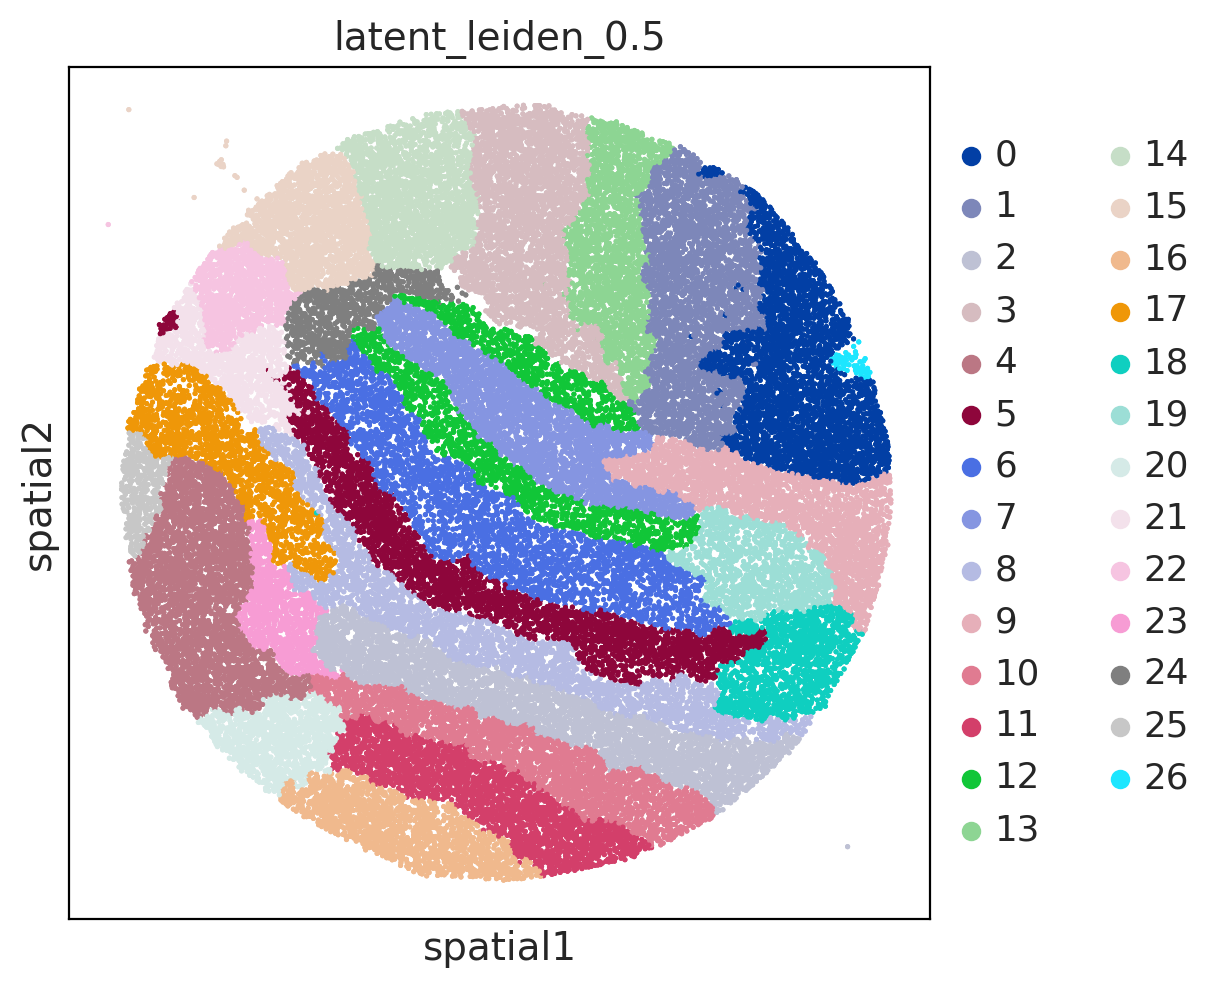

In [18]:
import squidpy as sq
sc.settings.set_figure_params(dpi=100, facecolor='white')

sq.pl.spatial_scatter(adata, color=latent_cluster_key, shape=None, figsize=(6, 6))

# Garfield

In [ ]:
import os
import pandas as pd
import numpy as np

os.chdir('/pri_exthome/zhouwg/project/Garfield')
os.getcwd()

In [ ]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
import numpy as np
import scipy.sparse as sp
import pandas as pd
from mudata import MuData

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

### 2.1 Define Training Function

In [ ]:
data_folder_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal/'
benchmarking_folder_path = "/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal"

In [ ]:
model_name = "garfield"
latent_key = f"{model_name}_latent"

In [10]:
def train_garfield_models(dataset,
                         cell_type_key,
                         niche_type_key=None,
                         adata_new=None,
                         n_start_run=1,
                         n_end_run=8,
                         n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16]):
    # Configure figure folder path
    # dataset_figure_folder_path = f"{figure_folder_path}/{dataset}/single_sample_method_benchmarking/" \
    #                              f"{model_name}/{current_timestamp}"
    # os.makedirs(dataset_figure_folder_path, exist_ok=True)

    # Create new adata to store results from training runs in storage-efficient way
    if adata_new is None:
        adata_original = sc.read_h5ad(data_folder_path + f"{dataset}.h5ad")
        adata_new = sc.AnnData(sp.csr_matrix(
            (adata_original.shape[0], adata_original.shape[1]),
            dtype=np.float32))
        adata_new.var_names = adata_original.var_names
        adata_new.obs_names = adata_original.obs_names
        adata_new.obs["cell_type"] = adata_original.obs[cell_type_key].values
        if niche_type_key in adata_original.obs.columns:
            adata_new.obs["niche_type"] = adata_original.obs[niche_type_key].values
        adata_new.obsm["spatial"] = adata_original.obsm["spatial"]
        del(adata_original)

    model_seeds = list(range(10))
    for run_number, n_neighbors in zip(np.arange(n_start_run, n_end_run+1), n_neighbor_list):
        # n_neighbors is here only used for the latent neighbor graph construction used for
        # UMAP generation and clustering as scVI is not a spatial method

        # Load trained SCVI results
        dataset='slideseqv2'
        root_dir = '/pri_exthome/zhouwg/project/spatial_data'
        file_fold = os.path.join(root_dir, str(dataset))
        adata = sc.read_h5ad(file_fold + '/slideseqv2.h5ad')
        adata.var_names_make_unique()

        # Store raw counts in adata.layers
        adata.layers["counts"] = sp.csr_matrix(np.round((np.exp(adata.X.toarray()) - 1)))
        adata.X = adata.layers['counts'].copy()

        ### modify parameter
        user_config = dict(
            ## Input options
            adata_list=adata,
            profile='spatial',
            data_type='single-modal',
            sample_col=None,
            weight=0.5,
            ## Preprocessing options
            graph_const_method='mu_std', # mu_std, Radius, KNN, Squidpy
            used_hvg=True,
            min_cells=3,
            min_features=0,
            keep_mt=False,
            target_sum=1e4,
            rna_n_top_features=3000,
            n_components=50,
            n_neighbors=n_neighbors,
            metric='euclidean',
            svd_solver='arpack',
            # datasets
            used_pca_feat=False,
            adj_key='connectivities',
            # data split parameters
            edge_val_ratio=0.1,
            edge_test_ratio=0.,
            node_val_ratio=0.1,
            node_test_ratio=0.,
            ## Model options
            augment_type='dropout',
            svd_q=5,
            use_FCencoder=True,
            conv_type='GAT', # GAT or GATv2Conv or GCN
            gnn_layer=2,
            hidden_dims=[128, 128],
            bottle_neck_neurons=20,
            cluster_num=20,
            drop_feature_rate=0.2,
            drop_edge_rate=0.2,
            num_heads=3,
            dropout=0.2,
            concat=True,
            used_edge_weight=False,
            used_DSBN=False,
            used_mmd=False,
            # data loader parameters
            num_neighbors=5,
            loaders_n_hops=2,
            edge_batch_size=4096,
            node_batch_size=256, # None
            # loss parameters
            include_edge_recon_loss=True,
            include_gene_expr_recon_loss=True,
            lambda_latent_contrastive_instanceloss=1.0,
            lambda_latent_contrastive_clusterloss=0.5,
            lambda_gene_expr_recon=1., #
            lambda_edge_recon=1., #
            lambda_latent_adj_recon_loss=2.,
            lambda_omics_recon_mmd_loss=0.2,
            # train parameters
            n_epochs_no_edge_recon=0,
            learning_rate=0.001,
            weight_decay=1e-05,
            gradient_clipping=5,
            # other parameters
            latent_key='garfield_latent',
            reload_best_model=True,
            use_early_stopping=True,
            early_stopping_kwargs=None,
            monitor=True,
            device_id=0,
            seed=2024,
            verbose=True
        )
        dict_config = gf.settings.set_gf_params(user_config)

        from Garfield.model import Garfield
        # Initialize model
        model = Garfield(dict_config)

        start_time = time.time()

        # Train model
        model.train()

        # Compute latent neighbor graph
        # sc.pp.neighbors(model.adata,
        #                 use_rep=latent_key,
        #                 key_added=latent_key)
        #
        # # Compute UMAP embedding
        # sc.tl.umap(model.adata,
        #            neighbors_key=latent_key)

        # Measure time for model training
        end_time = time.time()
        elapsed_time = end_time - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"Duration of model training in run {run_number}: "
              f"{int(hours)} hours, {int(minutes)} minutes and {int(seconds)} seconds.")
        adata_new.uns[f"{model_name}_model_training_duration_run{run_number}"] = (
            elapsed_time)

        # Store latent representation
        adata_new.obsm[latent_key + f"_run{run_number}"] = model.adata.obsm[latent_key]

        # Store intermediate adata to disk
        adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

    # Store final adata to disk
    adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")